1. Làm thế nào để đánh giá chất lượng của các cạnh được phát hiện bởi Canny?

**Lý thuyết:**

Việc đánh giá chất lượng biên phát hiện được chia thành hai hướng:

- **Đánh giá định tính (Bằng mắt thường):** Dựa trên 3 tiêu chí cốt lõi của thuật toán:
  - *Tỷ lệ lỗi thấp (Low error rate):* Tìm được mọi cạnh thực tế, không nhận diện nhầm nhiễu thành cạnh.
  - *Định vị chính xác (Good localization):* Khoảng cách giữa cạnh dự đoán và cạnh thực tế phải cực kỳ nhỏ.
  - *Phản hồi đơn (Single response):* Đường viền chỉ mỏng 1 pixel, không bị đứt đoạn hay dày cộm.

- **Đánh giá định lượng (Toán học):** Yêu cầu đối chiếu với một ảnh chuẩn (Ground Truth).
  - Sử dụng chỉ số **Pratt's Figure of Merit (PFOM)** để đo khoảng cách sai lệch:
  $$PFOM = \frac{1}{\max(N_I, N_D)} \sum_{i=1}^{N_D} \frac{1}{1 + \alpha d_i^2}$$
  - Sử dụng chỉ số **SSIM (Structural Similarity Index)** để đo mức độ tương đồng về cấu trúc giữa hai ảnh kết quả.

Chỉ số SSIM (Độ tương đồng) giữa 2 thiết lập tham số: 0.8952


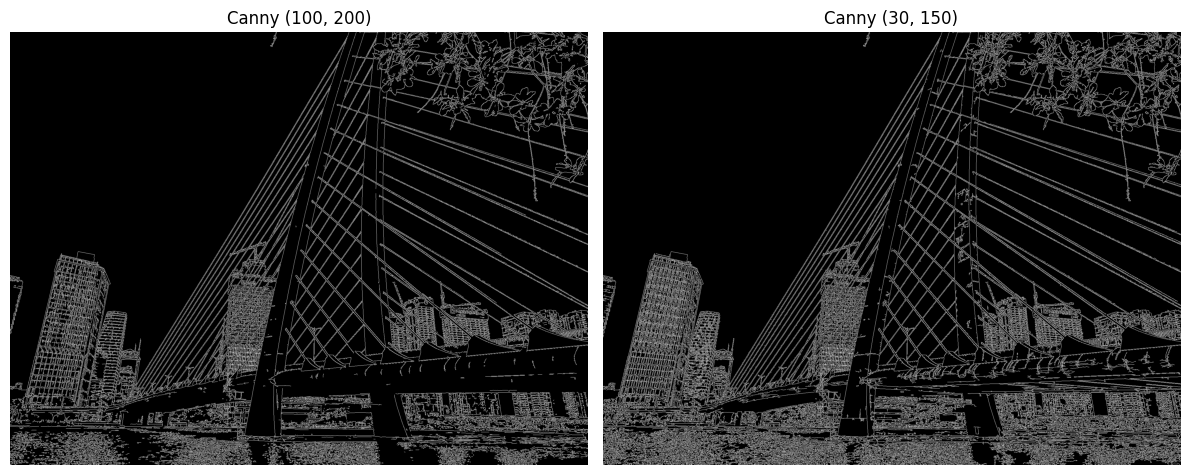

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Đọc ảnh xám (sử dụng ảnh từ thư mục data)
img_path = './data/input/caubason.jpg'  # Điều chỉnh đường dẫn nếu cần
try:
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Không tìm thấy ảnh tại {img_path}")
    else:
        # Tạo 2 kết quả Canny khác nhau
        edges_standard = cv2.Canny(img, 100, 200)  # Tham số mặc định
        edges_tuned = cv2.Canny(img, 30, 150)      # Tham số đã tinh chỉnh

        # Tính toán chỉ số SSIM
        score, diff = ssim(edges_standard, edges_tuned, full=True)
        print(f"Chỉ số SSIM (Độ tương đồng) giữa 2 thiết lập tham số: {score:.4f}")

        # Hiển thị
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(edges_standard, cmap='gray')
        axes[0].set_title('Canny (100, 200)')
        axes[1].imshow(edges_tuned, cmap='gray')
        axes[1].set_title('Canny (30, 150)')
        for ax in axes: 
            ax.axis('off')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Lỗi: {e}")

#### 2. Có những phương pháp nào khác để cải thiện hiệu suất của Canny?

**Lý thuyết:**

Thuật toán Canny cơ bản khá nhạy cảm với thông số cứng. Để tối ưu hóa trong các bài toán thực tế, ta áp dụng:

- **Auto-Canny (Ngưỡng động):** Thay vì hardcode ngưỡng bằng tay, ta sử dụng giá trị trung vị (median) của toàn bộ cường độ ảnh để tự động tính toán ra `low_threshold` và `high_threshold`.
- **Thay thế Gaussian bằng Bilateral Filter:** Gaussian làm mờ toàn bộ ảnh, dẫn đến việc làm mờ luôn cả các cạnh thực. Bilateral Filter là giải pháp ưu việt hơn vì nó giúp khử nhiễu xuất sắc nhưng vẫn bảo toàn độ sắc nét của đường biên (edge-preserving).
- **Tăng tốc độ bằng phần cứng:** Chạy thuật toán trên GPU thông qua module `cv2.cuda` để xử lý Real-time.

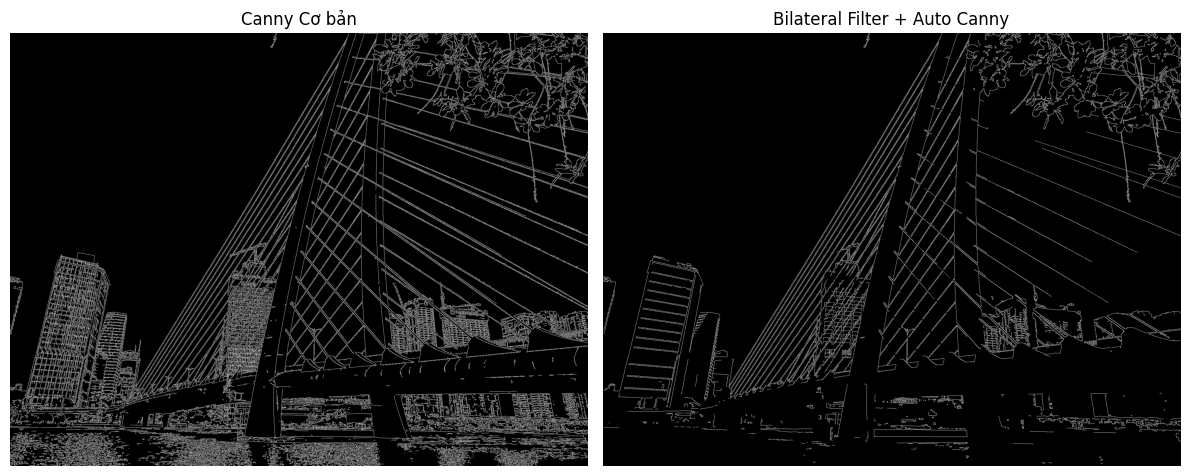

In [2]:
def auto_canny(image, sigma=0.33):
    """
    Tính toán ngưỡng Canny tự động dựa trên median
    """
    v = np.median(image)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    return cv2.Canny(image, lower, upper)

try:
    img_path = './data/input/caubason.jpg'  # Điều chỉnh đường dẫn nếu cần
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Dùng Bilateral Filter thay cho Gaussian (Khử nhiễu nhưng giữ nét cạnh)
        bilateral_filtered = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

        # Áp dụng Auto-Canny trên ảnh đã lọc
        edges_improved = auto_canny(bilateral_filtered)
        edges_original = cv2.Canny(img, 100, 200)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(edges_original, cmap='gray')
        axes[0].set_title('Canny Cơ bản')
        axes[1].imshow(edges_improved, cmap='gray')
        axes[1].set_title('Bilateral Filter + Auto Canny')
        for ax in axes: 
            ax.axis('off')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Lỗi: {e}")

#### 3. Canny có thể được sử dụng để phát hiện các cạnh trong ảnh màu không? Nếu có, thì như thế nào?

**Lý thuyết:**

Nguyên bản Canny chỉ chạy trên ảnh 1 kênh (Grayscale). Tuy nhiên, ta hoàn toàn có thể áp dụng cho ảnh màu để không bị mất chi tiết:

- **Cách 1 (Tiền xử lý):** Chuyển ảnh màu sang xám rồi chạy Canny. Nhược điểm là gặp hiện tượng "Isoluminance" (hai màu khác nhau nhưng có cùng độ chói sẽ bị hòa làm một, làm mất viền).
- **Cách 2 (Giữ chi tiết cao):** Tách ảnh màu thành 3 kênh độc lập (Red, Green, Blue). Chạy Canny trên từng kênh, sau đó gộp kết quả lại bằng phép toán logic `OR`. Việc này đảm bảo không bỏ sót bất kỳ đường viền nào chỉ xuất hiện ở một dải màu cụ thể.

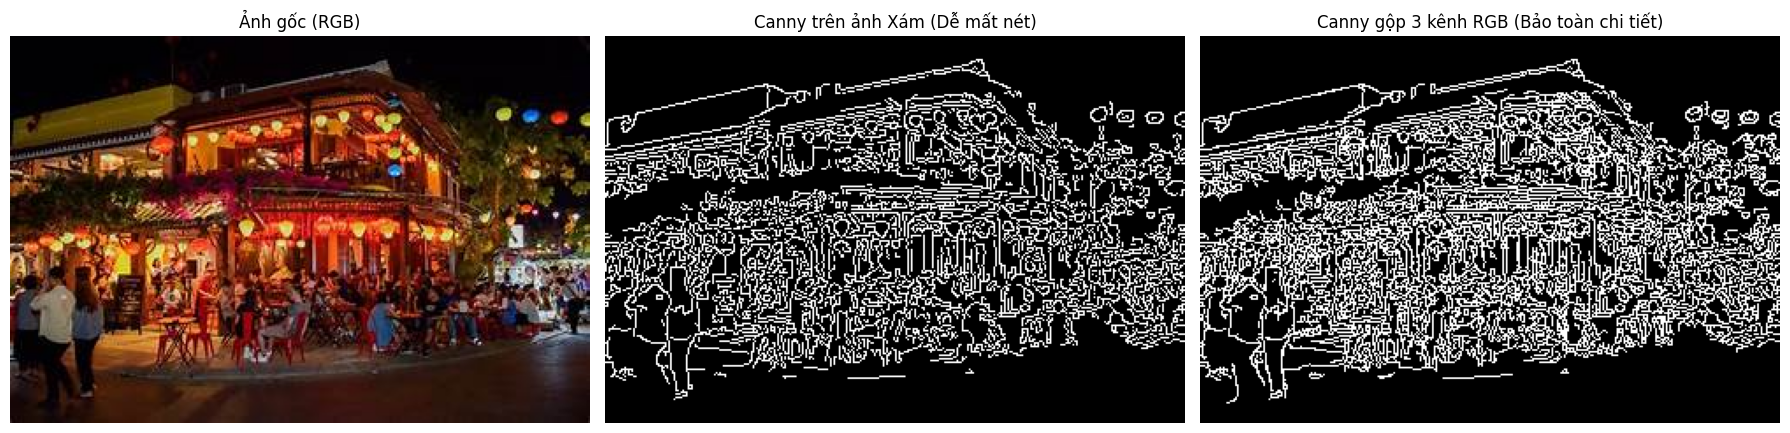

In [3]:
import cv2
import matplotlib.pyplot as plt

try:
    img_path = './data/input/khuphocohoian.jpg'  # Điều chỉnh đường dẫn nếu cần
    img_color = cv2.imread(img_path)
    
    if img_color is not None:
        # Chuyển hệ màu chuẩn RGB cho Matplotlib
        img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

        # Tách 3 kênh màu: R, G, B
        r, g, b = cv2.split(img_rgb)

        # Áp dụng Canny cho từng kênh
        edges_r = cv2.Canny(r, 100, 200)
        edges_g = cv2.Canny(g, 100, 200)
        edges_b = cv2.Canny(b, 100, 200)

        # Gộp kết quả bằng phép Bitwise OR
        edges_color_merged = cv2.bitwise_or(edges_r, edges_g)
        edges_color_merged = cv2.bitwise_or(edges_color_merged, edges_b)

        # So sánh: Canny trên ảnh xám vs Canny gộp 3 kênh
        gray_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        edges_gray = cv2.Canny(gray_img, 100, 200)

        # ==========================================
        # CẬP NHẬT: Tạo 1 hàng, 3 cột với kích thước rộng hơn (18, 5)
        # ==========================================
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Ảnh 1: Ảnh gốc
        axes[0].imshow(img_rgb)
        axes[0].set_title('Ảnh gốc (RGB)', fontsize=12)
        
        # Ảnh 2: Canny trên ảnh Xám
        axes[1].imshow(edges_gray, cmap='gray')
        axes[1].set_title('Canny trên ảnh Xám (Dễ mất nét)', fontsize=12)
        
        # Ảnh 3: Canny gộp 3 kênh
        axes[2].imshow(edges_color_merged, cmap='gray')
        axes[2].set_title('Canny gộp 3 kênh RGB (Bảo toàn chi tiết)', fontsize=12)
        
        # Ẩn trục tọa độ cho cả 3 ảnh
        for ax in axes: 
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Không tìm thấy ảnh. Vui lòng kiểm tra lại đường dẫn!")
except Exception as e:
    print(f"Lỗi: {e}")

#### 4. Làm thế nào để áp dụng Canny cho các video?

**Lý thuyết:**

Video bản chất là một chuỗi các khung hình tĩnh (frames) chạy liên tục. Việc áp dụng Canny cho video thực chất là tạo một vòng lặp pipeline qua từng khung hình: Đọc Frame → Chuyển Xám → Tiền xử lý (Gaussian/Bilateral) → Chạy `cv2.Canny()` → Hiển thị hoặc ghi lại vào video mới.

**Lưu ý:** Khi xử lý video, nhiễu ánh sáng thay đổi liên tục sẽ gây ra hiện tượng cạnh bị nhấp nháy (Temporal Flickering). Cần tối ưu tham số và quản lý FPS tốt để video mượt mà.

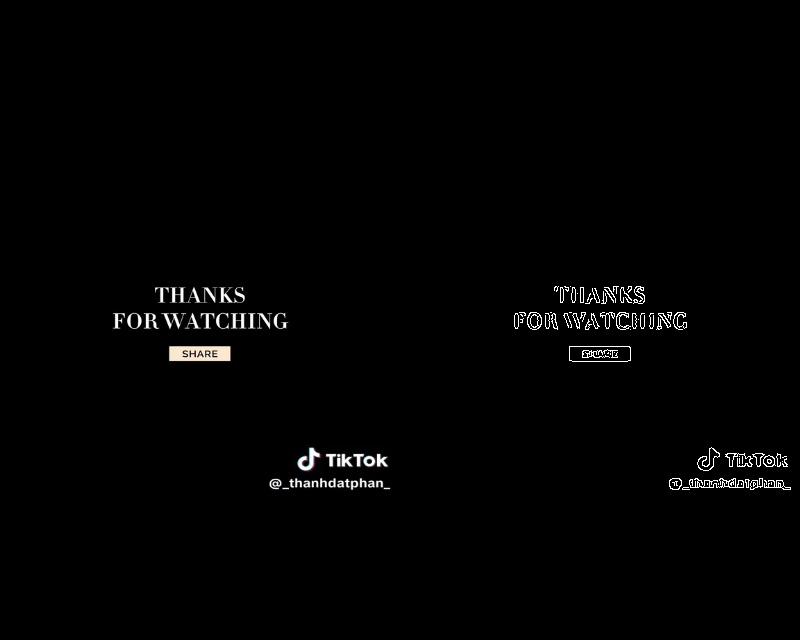

Đã hoàn thành hiển thị.


In [4]:
import cv2
import numpy as np
from IPython.display import display, Image, clear_output
import time

# Đường dẫn tới video của bạn
video_path = './data/input/HoiAn.mp4'  
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Không thể mở video. Vui lòng kiểm tra lại đường dẫn!")
else:
    try:
        print("Đang phát video trực tiếp... (Nhấn nút Stop/Interrupt trên Colab để dừng)")
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break # Hết video
            
            # (Tùy chọn) Thu nhỏ khung hình để video phát mượt hơn trên trình duyệt
            # Bạn có thể bỏ dòng này nếu muốn giữ nguyên kích thước gốc
            frame = cv2.resize(frame, (400, 640))

            # 1. Xử lý thuật toán Canny
            gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            blurred = cv2.GaussianBlur(gray_frame, (5, 5), 0)
            edges_frame = cv2.Canny(blurred, 50, 150)
            
            # 2. Chuyển ảnh xám Canny sang không gian 3 kênh BGR để có thể ghép
            edges_bgr = cv2.cvtColor(edges_frame, cv2.COLOR_GRAY2BGR)
            
            # 3. Ghép ngang 2 frame (Trái: Gốc, Phải: Canny)
            combined_frame = cv2.hconcat([frame, edges_bgr])
            
            # ==========================================
            # THỦ THUẬT HIỂN THỊ VIDEO TRÊN COLAB/JUPYTER
            # ==========================================
            # Chuyển đổi ma trận ảnh thành chuỗi byte định dạng JPEG
            ret, buffer = cv2.imencode('.jpg', combined_frame)
            
            # Xóa khung hình cũ (wait=True giúp việc xóa mượt hơn, không bị nháy màn hình)
            clear_output(wait=True)
            
            # Hiển thị khung hình mới
            display(Image(data=buffer.tobytes()))
            
            # Thêm độ trễ nhỏ để video không chạy quá nhanh (30ms ~ 30 FPS)
            time.sleep(0.03)
            
    except KeyboardInterrupt:
        # Xử lý khi bạn bấm nút Stop (Interrupt kernel) trên Colab
        print("Đã buộc dừng phát video.")
    finally:
        # Luôn nhớ giải phóng bộ nhớ khi kết thúc
        cap.release()
        print("Đã hoàn thành hiển thị.")